In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries load ho gayi!")

Libraries load ho gayi!


In [2]:
df = sns.load_dataset('titanic')

print("Dataset load ho gaya!")
print("Kitne passengers hain:", len(df))

Dataset load ho gaya!
Kitne passengers hain: 891


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [5]:
# Age ki missing values median se fill karo
df['age'].fillna(df['age'].median(), inplace=True)

# Embarked ki missing values fill karo
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Deck column delete karo
df.drop(columns=['deck'], inplace=True)

print("Data clean ho gaya!")
df.isnull().sum()

Data clean ho gaya!


/tmp/ipykernel_2165/2571177392.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_2165/2571177392.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [6]:
survival_by_gender = df.groupby('sex')['survived'].mean() * 100
print("Survival Rate by Gender (%):")
print(survival_by_gender.round(2))

Survival Rate by Gender (%):
sex
female    74.20
male      18.89
Name: survived, dtype: float64


In [7]:
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
print("Survival Rate by Class (%):")
print(survival_by_class.round(2))

Survival Rate by Class (%):
pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64


In [8]:
# Age groups banao
def age_group(age):
    if age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Teen'
    elif age <= 40:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)

survival_by_age = df.groupby('age_group')['survived'].mean() * 100
print("Survival Rate by Age Group (%):")
print(survival_by_age.round(2))

Survival Rate by Age Group (%):
age_group
Adult     36.05
Child     57.97
Senior    36.67
Teen      42.86
Name: survived, dtype: float64


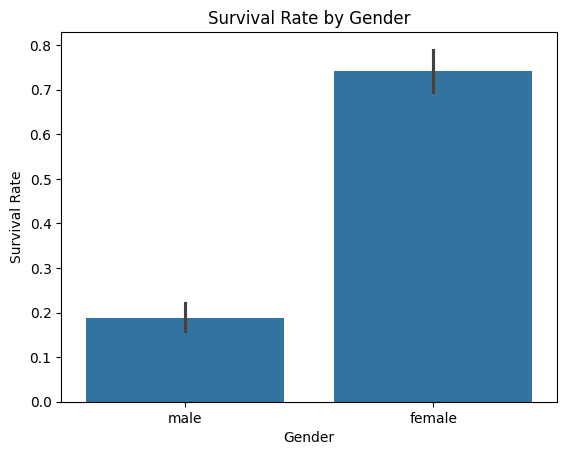

In [9]:
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

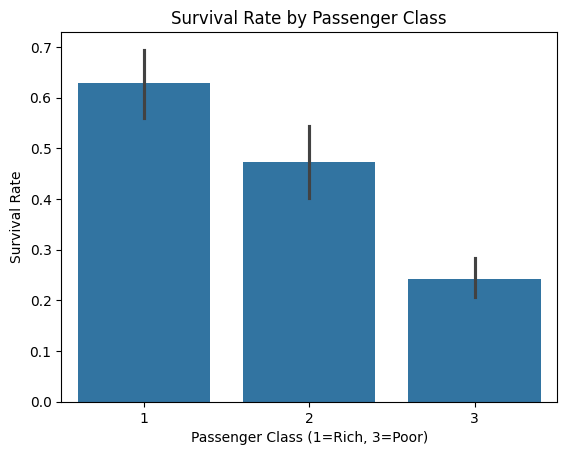

In [10]:
sns.barplot(x='pclass', y='survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1=Rich, 3=Poor)')
plt.ylabel('Survival Rate')
plt.show()

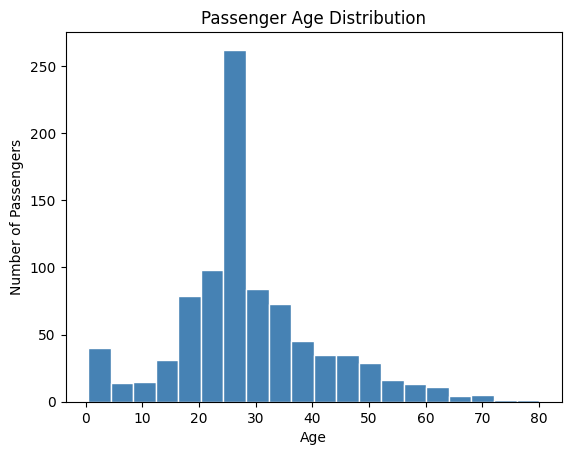

In [11]:
df['age'].plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()